In [1]:
# Cell 1: Imports and configuration

import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path("/Volumes/Utkash SSD/SIH26143")

DEVICE = "cpu"

# Phase 2 output
GEOJSON_PATH = BASE / "spill_detection_result.geojson"

# Hindcasting configuration
BACKTRACK_HOURS = 24
TIME_STEP_HOURS = 1

print("Phase 3: Oceanographic + Meteorological Hindcasting")
print("Dataset:", BASE)
print("Spill GeoJSON:", GEOJSON_PATH)
print("GeoJSON exists:", GEOJSON_PATH.exists())
print("Backtracking window:", BACKTRACK_HOURS, "hours")
print("Time step:", TIME_STEP_HOURS, "hour")

Phase 3: Oceanographic + Meteorological Hindcasting
Dataset: /Volumes/Utkash SSD/SIH26143
Spill GeoJSON: /Volumes/Utkash SSD/SIH26143/spill_detection_result.geojson
GeoJSON exists: True
Backtracking window: 24 hours
Time step: 1 hour


In [2]:
# Cell 2: Load spill detection result

with open(GEOJSON_PATH, "r") as f:
    spill_result = json.load(f)

spill_properties = spill_result["properties"]
spill_geometry = spill_result["geometry"]

spill_latitude = spill_properties["latitude"]
spill_longitude = spill_properties["longitude"]

print("Spill result loaded successfully.")
print()
print("Image:", spill_properties["image"])
print(f"Latitude : {spill_latitude:.6f}")
print(f"Longitude: {spill_longitude:.6f}")
print("Geometry:", spill_geometry["type"])
print("Area:", f"{spill_properties['area_km2']:.6f} km²")

Spill result loaded successfully.

Image: 00000.tif
Latitude : 55.241822
Longitude: 4.053104
Geometry: Polygon
Area: 0.925739 km²


In [3]:
# Cell 3: Check available spill timestamp metadata

timestamp_keys = [
    "timestamp",
    "datetime",
    "date",
    "acquisition_time",
    "acquisition_date",
    "observation_time",
    "observation_date"
]

available_timestamps = {
    key: spill_properties[key]
    for key in timestamp_keys
    if key in spill_properties
}

if available_timestamps:
    print("Timestamp information found:")
    for key, value in available_timestamps.items():
        print(f"  {key}: {value}")
else:
    print("No timestamp information is available in the Phase 2 GeoJSON.")
    print()
    print("Available metadata:")
    for key, value in spill_properties.items():
        print(f"  {key}: {value}")

No timestamp information is available in the Phase 2 GeoJSON.

Available metadata:
  image: 00000.tif
  latitude: 55.24182164229434
  longitude: 4.053103837300581
  area_km2: 0.9257386644219509
  area_pixels: 16549
  perimeter_pixels: 917.7199034690857
  aspect_ratio: 2.25
  prediction_threshold: 0.5


In [4]:
# Cell 4: Inspect SAR image metadata

import rasterio

sample_image_path = BASE / "Oil" / spill_properties["image"]

with rasterio.open(sample_image_path) as src:
    image_tags = src.tags()
    image_subdatasets = src.subdatasets

print("Image:", sample_image_path.name)

print("\nImage metadata tags:")

if image_tags:
    for key, value in image_tags.items():
        print(f"  {key}: {value}")
else:
    print("  No metadata tags found.")

print("\nSubdatasets:")

if image_subdatasets:
    for item in image_subdatasets:
        print(" ", item)
else:
    print("  None")

Image: 00000.tif

Image metadata tags:
  TIFFTAG_XRESOLUTION: 1
  TIFFTAG_YRESOLUTION: 1
  TIFFTAG_RESOLUTIONUNIT: 1 (unitless)
  AREA_OR_POINT: Area

Subdatasets:
  None


In [5]:
# Cell 5: Extract acquisition timestamp from image metadata

import re
from datetime import datetime

timestamp_candidates = []

for key, value in image_tags.items():
    text = f"{key} {value}"

    matches = re.findall(
        r"\b20\d{2}[-/:]\d{1,2}[-/:]\d{1,2}"
        r"(?:[T\s]\d{1,2}:\d{2}(?::\d{2}(?:\.\d+)?)?)?",
        text
    )

    for match in matches:
        timestamp_candidates.append(
            (key, value, match)
        )

if timestamp_candidates:
    print("Possible acquisition timestamps found:\n")

    for key, value, match in timestamp_candidates:
        print(f"  {key}: {match}")
else:
    print("No acquisition timestamp found in the TIFF metadata.")

No acquisition timestamp found in the TIFF metadata.


In [6]:
# Cell 6: Search dataset for metadata files

metadata_extensions = {
    ".xml",
    ".json",
    ".csv",
    ".txt",
    ".safe"
}

metadata_files = []

for path in BASE.rglob("*"):
    if path.is_file() and path.suffix.lower() in metadata_extensions:
        metadata_files.append(path)

print("Potential metadata files found:", len(metadata_files))

for path in metadata_files[:50]:
    print(path.relative_to(BASE))

if len(metadata_files) > 50:
    print(f"\n...and {len(metadata_files) - 50} more")

Potential metadata files found: 0


In [7]:
# Cell 7: Define observation timestamp

OBSERVATION_TIMESTAMP = None

if OBSERVATION_TIMESTAMP is None:
    print("Observation timestamp: NOT PROVIDED")
    print()
    print("Phase 3 hindcasting requires an observation date/time.")
    print("Provide the timestamp when an actual investigation is created.")
else:
    print("Observation timestamp:", OBSERVATION_TIMESTAMP)

Observation timestamp: NOT PROVIDED

Phase 3 hindcasting requires an observation date/time.
Provide the timestamp when an actual investigation is created.


In [8]:
# Cell 8: Define environmental data interface

environmental_data = {
    "timestamp": None,
    "latitude": float(spill_latitude),
    "longitude": float(spill_longitude),
    "wind": {
        "speed": None,
        "direction": None
    },
    "ocean_current": {
        "speed": None,
        "direction": None
    }
}

print("Environmental data structure initialized.")
print()
print(json.dumps(environmental_data, indent=2))

Environmental data structure initialized.

{
  "timestamp": null,
  "latitude": 55.24182164229434,
  "longitude": 4.053103837300581,
  "wind": {
    "speed": null,
    "direction": null
  },
  "ocean_current": {
    "speed": null,
    "direction": null
  }
}


In [9]:
# Cell 9: Define hindcasting parameters

hindcast_config = {
    "backtrack_hours": BACKTRACK_HOURS,
    "time_step_hours": TIME_STEP_HOURS,

    # Initial uncertainty around detected spill location
    "initial_position_uncertainty_km": 1.0,

    # Number of particles used for trajectory estimation
    "num_particles": 1000,

    # Wind influence on surface oil movement
    "windage_factor": 0.03
}

print("Hindcasting configuration:")
print(json.dumps(hindcast_config, indent=2))

Hindcasting configuration:
{
  "backtrack_hours": 24,
  "time_step_hours": 1,
  "initial_position_uncertainty_km": 1.0,
  "num_particles": 1000,
  "windage_factor": 0.03
}


In [10]:
# Cell 10: Validate hindcast inputs

required_inputs = {
    "latitude": spill_latitude,
    "longitude": spill_longitude,
    "observation_timestamp": OBSERVATION_TIMESTAMP
}

missing_inputs = [
    name
    for name, value in required_inputs.items()
    if value is None
]

print("Hindcast input validation")

if missing_inputs:
    print("Missing inputs:")
    for item in missing_inputs:
        print(f"  - {item}")

    print("\nHindcasting cannot start until all required inputs are available.")
else:
    print("All required inputs are available.")
    print("Ready to retrieve environmental data.")

Hindcast input validation
Missing inputs:
  - observation_timestamp

Hindcasting cannot start until all required inputs are available.


In [11]:
# Cell 11: Build hindcast time window

from datetime import timedelta

def build_hindcast_window(observation_timestamp, backtrack_hours):
    if observation_timestamp is None:
        raise ValueError(
            "Observation timestamp is required for hindcasting."
        )

    observation_timestamp = pd.Timestamp(
        observation_timestamp,
        tz="UTC"
    )

    start_time = (
        observation_timestamp
        - pd.Timedelta(hours=backtrack_hours)
    )

    return start_time, observation_timestamp


if OBSERVATION_TIMESTAMP is not None:
    hindcast_start, hindcast_end = build_hindcast_window(
        OBSERVATION_TIMESTAMP,
        BACKTRACK_HOURS
    )

    print("Hindcast window:")
    print("Start:", hindcast_start)
    print("End  :", hindcast_end)
else:
    print("Observation timestamp not available.")
    print("Hindcast window will be created when timestamp is provided.")

Observation timestamp not available.
Hindcast window will be created when timestamp is provided.


In [12]:
# Cell 12: Environmental data loader interface

class EnvironmentalDataLoader:
    def __init__(self):
        self.wind_data = None
        self.current_data = None

    def load_wind(self, start_time, end_time, latitude, longitude):
        raise NotImplementedError(
            "Wind data provider has not been connected yet."
        )

    def load_ocean_current(self, start_time, end_time, latitude, longitude):
        raise NotImplementedError(
            "Ocean-current data provider has not been connected yet."
        )

    def validate(self):
        return (
            self.wind_data is not None
            and self.current_data is not None
        )


environment_loader = EnvironmentalDataLoader()

print("Environmental data loader initialized.")
print("Wind provider: not connected")
print("Ocean-current provider: not connected")
print("Ready for environmental data integration.")

Environmental data loader initialized.
Wind provider: not connected
Ocean-current provider: not connected
Ready for environmental data integration.


In [13]:
# Cell 13: Define environmental data requirements

environmental_requirements = {
    "wind": {
        "variables": [
            "10m_u_wind",
            "10m_v_wind"
        ],
        "temporal_resolution": "hourly",
        "required_for": "surface wind forcing"
    },

    "ocean_current": {
        "variables": [
            "eastward_current",
            "northward_current"
        ],
        "temporal_resolution": "provider dependent",
        "required_for": "surface ocean drift"
    }
}

print("Environmental data requirements:\n")
print(json.dumps(environmental_requirements, indent=2))

Environmental data requirements:

{
  "wind": {
    "variables": [
      "10m_u_wind",
      "10m_v_wind"
    ],
    "temporal_resolution": "hourly",
    "required_for": "surface wind forcing"
  },
  "ocean_current": {
    "variables": [
      "eastward_current",
      "northward_current"
    ],
    "temporal_resolution": "provider dependent",
    "required_for": "surface ocean drift"
  }
}


In [14]:
# Cell 14: Define environmental data query region

QUERY_RADIUS_DEG = 1.0

environment_query = {
    "latitude_min": spill_latitude - QUERY_RADIUS_DEG,
    "latitude_max": spill_latitude + QUERY_RADIUS_DEG,
    "longitude_min": spill_longitude - QUERY_RADIUS_DEG,
    "longitude_max": spill_longitude + QUERY_RADIUS_DEG,
    "start_time": None,
    "end_time": None
}

print("Environmental data query region:")
print(
    f"Latitude : "
    f"{environment_query['latitude_min']:.4f} → "
    f"{environment_query['latitude_max']:.4f}"
)
print(
    f"Longitude: "
    f"{environment_query['longitude_min']:.4f} → "
    f"{environment_query['longitude_max']:.4f}"
)
print("Start time:", environment_query["start_time"])
print("End time  :", environment_query["end_time"])

Environmental data query region:
Latitude : 54.2418 → 56.2418
Longitude: 3.0531 → 5.0531
Start time: None
End time  : None


In [15]:
# Cell 15: Validate environmental data query

def validate_environmental_query(query):
    required_fields = [
        "latitude_min",
        "latitude_max",
        "longitude_min",
        "longitude_max",
        "start_time",
        "end_time"
    ]

    missing_fields = [
        field
        for field in required_fields
        if query.get(field) is None
    ]

    if missing_fields:
        return False, missing_fields

    return True, []


query_valid, missing_fields = validate_environmental_query(
    environment_query
)

if query_valid:
    print("Environmental query is ready.")
else:
    print("Environmental query is incomplete.")
    print("Missing:", ", ".join(missing_fields))

Environmental query is incomplete.
Missing: start_time, end_time


In [16]:
# Cell 16 — Load DARTIS metadata correctly

import pandas as pd
from pathlib import Path

DARTIS_PATH = Path("/Volumes/Utkash SSD/SIH26143/DARTIS_2019.tab")

# Exact column names from the PANGAEA data table
DARTIS_COLUMNS = [
    "image_set",
    "image",
    "xml",
    "tag",
    "patch_name",
    "start_time",
    "end_time",
    "sentinel_id",
    "patch_width",
    "patch_height",
    "patch_ul_lon",
    "patch_ul_lat",
    "patch_ur_lon",
    "patch_ur_lat",
    "patch_br_lon",
    "patch_br_lat",
    "patch_bl_lon",
    "patch_bl_lat",
    "obj_ul_lon",
    "obj_ul_lat",
    "obj_ur_lon",
    "obj_ur_lat",
    "obj_br_lon",
    "obj_br_lat",
    "obj_bl_lon",
    "obj_bl_lat",
    "obj_xmin",
    "obj_ymin",
    "obj_xmax",
    "obj_ymax",
    "label_size",
]

dartis_df = pd.read_csv(
    DARTIS_PATH,
    sep="\t",
    skiprows=51,
    header=None,
    names=DARTIS_COLUMNS,
)

# Convert numeric fields
numeric_columns = [
    "patch_width", "patch_height",
    "patch_ul_lon", "patch_ul_lat",
    "patch_ur_lon", "patch_ur_lat",
    "patch_br_lon", "patch_br_lat",
    "patch_bl_lon", "patch_bl_lat",
    "obj_ul_lon", "obj_ul_lat",
    "obj_ur_lon", "obj_ur_lat",
    "obj_br_lon", "obj_br_lat",
    "obj_bl_lon", "obj_bl_lat",
    "obj_xmin", "obj_ymin",
    "obj_xmax", "obj_ymax",
    "label_size",
]

for col in numeric_columns:
    dartis_df[col] = pd.to_numeric(dartis_df[col], errors="coerce")

# Parse timestamps
dartis_df["start_time"] = pd.to_datetime(
    dartis_df["start_time"],
    errors="coerce",
    utc=True,
)

dartis_df["end_time"] = pd.to_datetime(
    dartis_df["end_time"],
    errors="coerce",
    utc=True,
)

print("Dataset shape:", dartis_df.shape)

print("\nImage-set distribution:")
print(dartis_df["image_set"].value_counts())

print("\nDate range:")
print(dartis_df["start_time"].min())
print("→")
print(dartis_df["start_time"].max())

print("\nFirst 3 properly parsed rows:")
display(
    dartis_df[
        [
            "image_set",
            "patch_name",
            "start_time",
            "end_time",
            "sentinel_id",
            "patch_ul_lon",
            "patch_ul_lat",
            "obj_ul_lon",
            "obj_ul_lat",
            "label_size",
        ]
    ].head(3)
)

Dataset shape: (5514, 31)

Image-set distribution:
image_set
ow    2283
nw    1939
oc     941
nc     351
Name: count, dtype: int64

Date range:
2019-01-01 03:42:35+00:00
→
2019-12-31 15:47:53+00:00

First 3 properly parsed rows:


,image_set,patch_name,start_time,end_time,sentinel_id,patch_ul_lon,patch_ul_lat,obj_ul_lon,obj_ul_lat,label_size
0,ow,S1_20190104_155638_155818_VV_2,2019-01-04 15:56:38+00:00,2019-01-04 15:58:18+00:00,S1A_IW_GRDH_1SDV_20190104T155703_20190104T1557...,31.972816,31.619308,32.026831,31.679563,1860.0
1,ow,S1_20190110_155611_155635_VV_9,2019-01-10 15:56:11+00:00,2019-01-10 15:56:35+00:00,S1B_IW_GRDH_1SDV_20190110T155611_20190110T1556...,30.573309,31.505394,30.622838,31.570404,1034.0
2,ow,S1_20190110_155611_155635_VV_10,2019-01-10 15:56:11+00:00,2019-01-10 15:56:35+00:00,S1B_IW_GRDH_1SDV_20190110T155611_20190110T1556...,31.128362,31.644936,31.189367,31.708369,247.0


In [17]:
# Cell 17 — Select a representative oil-spill observation

oil_df = dartis_df[
    (dartis_df["image_set"] == "ow") &
    (dartis_df["label_size"].notna()) &
    (dartis_df["obj_ul_lon"].notna()) &
    (dartis_df["obj_ul_lat"].notna())
].copy()

# Largest annotated oil object
selected_idx = oil_df["label_size"].idxmax()
selected_spill = oil_df.loc[selected_idx]

print("Selected oil-spill observation")
print("-" * 60)

print("Patch name :", selected_spill["patch_name"])
print("Image      :", selected_spill["image"])
print("Start time :", selected_spill["start_time"])
print("End time   :", selected_spill["end_time"])
print("Sentinel ID:", selected_spill["sentinel_id"])
print("Label size :", int(selected_spill["label_size"]), "pixels")

print("\nOil-object coordinates:")
print(
    f"UL: ({selected_spill['obj_ul_lon']:.6f}, "
    f"{selected_spill['obj_ul_lat']:.6f})"
)
print(
    f"UR: ({selected_spill['obj_ur_lon']:.6f}, "
    f"{selected_spill['obj_ur_lat']:.6f})"
)
print(
    f"BR: ({selected_spill['obj_br_lon']:.6f}, "
    f"{selected_spill['obj_br_lat']:.6f})"
)
print(
    f"BL: ({selected_spill['obj_bl_lon']:.6f}, "
    f"{selected_spill['obj_bl_lat']:.6f})"
)

Selected oil-spill observation
------------------------------------------------------------
Patch name : S1_20191019_155647_155827_VV_0
Image      : ow-0827.jpg
Start time : 2019-10-19 15:56:47+00:00
End time   : 2019-10-19 15:58:27+00:00
Sentinel ID: S1A_IW_GRDH_1SDV_20191019T155737_20191019T155802_029530_035C5B_E72A.SAFE;S1A_IW_GRDH_1SDV_20191019T155712_20191019T155737_029530_035C5B_D123.SAFE
Label size : 4705064 pixels

Oil-object coordinates:
UL: (29.985659, 32.304672)
UR: (30.425230, 32.373451)
BR: (30.335228, 32.779276)
BL: (29.895657, 32.710497)


In [18]:
# Cell 18 — Calculate oil-spill centroid

lon_values = [
    selected_spill["obj_ul_lon"],
    selected_spill["obj_ur_lon"],
    selected_spill["obj_br_lon"],
    selected_spill["obj_bl_lon"],
]

lat_values = [
    selected_spill["obj_ul_lat"],
    selected_spill["obj_ur_lat"],
    selected_spill["obj_br_lat"],
    selected_spill["obj_bl_lat"],
]

spill_lon = float(np.mean(lon_values))
spill_lat = float(np.mean(lat_values))

observation_timestamp = selected_spill["start_time"]

print("Phase 3 observation")
print("-" * 50)
print(f"Latitude  : {spill_lat:.6f}")
print(f"Longitude : {spill_lon:.6f}")
print(f"Timestamp : {observation_timestamp}")
print(f"Sentinel  : {selected_spill['sentinel_id']}")
print(f"Patch     : {selected_spill['patch_name']}")

Phase 3 observation
--------------------------------------------------
Latitude  : 32.541974
Longitude : 30.160444
Timestamp : 2019-10-19 15:56:47+00:00
Sentinel  : S1A_IW_GRDH_1SDV_20191019T155737_20191019T155802_029530_035C5B_E72A.SAFE;S1A_IW_GRDH_1SDV_20191019T155712_20191019T155737_029530_035C5B_D123.SAFE
Patch     : S1_20191019_155647_155827_VV_0


In [19]:
# Cell 19 — Build hindcast time window

BACKTRACK_HOURS = 24
TIME_STEP_HOURS = 1

start_time = observation_timestamp - pd.Timedelta(hours=BACKTRACK_HOURS)
end_time = observation_timestamp

hindcast_times = pd.date_range(
    start=start_time,
    end=end_time,
    freq=f"{TIME_STEP_HOURS}h",
    tz="UTC",
)

print("Hindcast window")
print("-" * 50)
print(f"Observation : {observation_timestamp}")
print(f"Start       : {start_time}")
print(f"End         : {end_time}")
print(f"Time steps  : {len(hindcast_times)}")

print("\nFirst 3:")
print(hindcast_times[:3])

print("\nLast 3:")
print(hindcast_times[-3:])

Hindcast window
--------------------------------------------------
Observation : 2019-10-19 15:56:47+00:00
Start       : 2019-10-18 15:56:47+00:00
End         : 2019-10-19 15:56:47+00:00
Time steps  : 25

First 3:
DatetimeIndex(['2019-10-18 15:56:47+00:00', '2019-10-18 16:56:47+00:00',
               '2019-10-18 17:56:47+00:00'],
              dtype='datetime64[ns, UTC]', freq='h')

Last 3:
DatetimeIndex(['2019-10-19 13:56:47+00:00', '2019-10-19 14:56:47+00:00',
               '2019-10-19 15:56:47+00:00'],
              dtype='datetime64[ns, UTC]', freq='h')


In [20]:
# CDS API credentials

from pathlib import Path
import getpass

cdsapirc = Path.home() / ".cdsapirc"

api_key = getpass.getpass("Paste your CDS API key: ")

cdsapirc.write_text(
    f"url: https://cds.climate.copernicus.eu/api\n"
    f"key: {api_key}\n"
)

print(f"CDS configuration created at: {cdsapirc}")

Paste your CDS API key: ··········
CDS configuration created at: /Users/utkarshsmac/.cdsapirc


In [21]:
# Cell 20 — Download ERA5 10m wind data

import cdsapi
import xarray as xr

ERA5_FILE = BASE / "era5_wind_2019-10-18_19.nc"

client = cdsapi.Client()

request = {
    "product_type": ["reanalysis"],
    "variable": [
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
    ],
    "year": ["2019"],
    "month": ["10"],
    "day": ["18", "19"],
    "time": [
        "00:00", "01:00", "02:00", "03:00",
        "04:00", "05:00", "06:00", "07:00",
        "08:00", "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00", "15:00",
        "16:00", "17:00", "18:00", "19:00",
        "20:00", "21:00", "22:00", "23:00",
    ],
    "area": [34.0, 28.0, 30.0, 33.0],
    "data_format": "netcdf",
    "download_format": "unarchived",
}

client.retrieve(
    "reanalysis-era5-single-levels",
    request,
    str(ERA5_FILE),
)

print("ERA5 file downloaded:")
print(ERA5_FILE)
print(f"Size: {ERA5_FILE.stat().st_size / (1024**2):.2f} MB")

era5 = xr.open_dataset(ERA5_FILE)

print("\nDataset:")
print(era5)

print("\nVariables:")
print(list(era5.data_vars))

2026-09-06 20:40:34,533 INFO Request ID is 61a05922-abcb-47d6-b1a8-c0b5b70ef969
2026-09-06 20:40:34,773 INFO status has been updated to accepted
2026-09-06 20:40:49,274 INFO status has been updated to successful


9854e7d37b3647dce78b13a39f28befd.nc:   0%|          | 0.00/114k [00:00<?, ?B/s]

ERA5 file downloaded:
/Volumes/Utkash SSD/SIH26143/era5_wind_2019-10-18_19.nc
Size: 0.11 MB

Dataset:
<xarray.Dataset> Size: 139kB
Dimensions:     (valid_time: 48, latitude: 17, longitude: 21)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 384B 2019-10-18 ... 2019-10-19T23...
  * latitude    (latitude) float64 136B 34.0 33.75 33.5 ... 30.5 30.25 30.0
  * longitude   (longitude) float64 168B 28.0 28.25 28.5 ... 32.5 32.75 33.0
    number      int64 8B ...
    expver      (valid_time) <U4 768B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 69kB ...
    v10         (valid_time, latitude, longitude) float32 69kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-06T14:35 GRIB to CDM+CF via c

In [22]:
# Cell 21 — Extract wind at spill location

spill_lat = float(spill_lat)
spill_lon = float(spill_lon)

wind_at_spill = era5.sel(
    latitude=spill_lat,
    longitude=spill_lon,
    method="nearest"
)

print("Nearest ERA5 grid point:")
print(f"Latitude : {float(wind_at_spill.latitude.values):.2f}")
print(f"Longitude: {float(wind_at_spill.longitude.values):.2f}")

print("\nWind data:")
print(wind_at_spill[["u10", "v10"]])

Nearest ERA5 grid point:
Latitude : 32.50
Longitude: 30.25

Wind data:
<xarray.Dataset> Size: 2kB
Dimensions:     (valid_time: 48)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 384B 2019-10-18 ... 2019-10-19T23...
    number      int64 8B ...
    latitude    float64 8B 32.5
    longitude   float64 8B 30.25
    expver      (valid_time) <U4 768B ...
Data variables:
    u10         (valid_time) float32 192B ...
    v10         (valid_time) float32 192B ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-06T14:35 GRIB to CDM+CF via cfgrib-0.9.1...


In [23]:
# Cell 22 — Calculate wind speed and direction

import numpy as np
import pandas as pd

wind_df = wind_at_spill[["u10", "v10"]].to_dataframe().reset_index()

wind_df["wind_speed_ms"] = np.sqrt(
    wind_df["u10"]**2 + wind_df["v10"]**2
)

# Meteorological direction: direction FROM which wind is coming
wind_df["wind_direction_deg"] = (
    np.degrees(
        np.arctan2(
            -wind_df["u10"],
            -wind_df["v10"]
        )
    ) + 360
) % 360

print(wind_df.head(10))

print("\nWind statistics:")
print(
    wind_df[
        ["wind_speed_ms", "wind_direction_deg"]
    ].describe()
)

           valid_time       u10       v10  number  latitude  longitude expver  \
0 2019-10-18 00:00:00 -0.980545 -4.538528       0      32.5      30.25   0001   
1 2019-10-18 01:00:00 -1.210251 -3.960495       0      32.5      30.25   0001   
2 2019-10-18 02:00:00 -0.881073 -3.583923       0      32.5      30.25   0001   
3 2019-10-18 03:00:00 -0.633331 -3.256989       0      32.5      30.25   0001   
4 2019-10-18 04:00:00 -0.400711 -2.851456       0      32.5      30.25   0001   
5 2019-10-18 05:00:00 -0.558975 -2.684677       0      32.5      30.25   0001   
6 2019-10-18 06:00:00 -1.102188 -2.335022       0      32.5      30.25   0001   
7 2019-10-18 07:00:00 -1.193253 -1.861191       0      32.5      30.25   0001   
8 2019-10-18 08:00:00  0.549866 -2.175018       0      32.5      30.25   0001   
9 2019-10-18 09:00:00  2.326981 -3.343933       0      32.5      30.25   0001   

   wind_speed_ms  wind_direction_deg  
0       4.643243           12.191315  
1       4.141283           16.

In [24]:
# Cell 23 — Prepare hourly wind data

wind_df = wind_at_spill[["u10", "v10"]].to_dataframe().reset_index()

# Remove unnecessary coordinate columns
wind_df = wind_df[["valid_time", "u10", "v10"]].copy()

# Calculate wind speed
wind_df["wind_speed_ms"] = np.sqrt(
    wind_df["u10"]**2 + wind_df["v10"]**2
)

# Meteorological wind direction:
# direction FROM which the wind is coming
wind_df["wind_direction_deg"] = (
    np.degrees(
        np.arctan2(
            -wind_df["u10"],
            -wind_df["v10"]
        )
    ) + 360
) % 360

print("Hourly wind data:")
print(wind_df.head())

print("\nWind statistics:")
print(wind_df[["wind_speed_ms", "wind_direction_deg"]].describe())

print("\nMaximum wind speed:",
      round(wind_df["wind_speed_ms"].max(), 2), "m/s")

Hourly wind data:
           valid_time       u10       v10  wind_speed_ms  wind_direction_deg
0 2019-10-18 00:00:00 -0.980545 -4.538528       4.643243           12.191315
1 2019-10-18 01:00:00 -1.210251 -3.960495       4.141283           16.992126
2 2019-10-18 02:00:00 -0.881073 -3.583923       3.690636           13.811707
3 2019-10-18 03:00:00 -0.633331 -3.256989       3.317994           11.004028
4 2019-10-18 04:00:00 -0.400711 -2.851456       2.879474            7.999298

Wind statistics:
       wind_speed_ms  wind_direction_deg
count      48.000000           48.000000
mean        2.906091          116.619286
std         1.257478          134.863464
min         0.416293            4.148987
25%         2.000311           22.755844
50%         2.725923           46.599747
75%         3.463961          309.141808
max         5.884716          358.340881

Maximum wind speed: 5.88 m/s


In [25]:
# Cell 24 — Verify Copernicus Marine Toolbox

import copernicusmarine

print("Copernicus Marine Toolbox:", copernicusmarine.__version__)

Copernicus Marine Toolbox: 2.4.1


In [26]:
# Cell 25 — Login to Copernicus Marine

import copernicusmarine

copernicusmarine.login()

INFO - 2026-09-06T15:11:05Z - Using existing credentials from /Users/utkarshsmac/.copernicusmarine/.copernicusmarine-credentials. Use --force-overwrite combined with credentials (specified by arguments, netrc file or environment variables) to always overwrite.


True

In [27]:
# Cell 26 — Inspect Mediterranean current dataset

import copernicusmarine

dataset_id = "cmems_mod_med_phy-cur_my_4.2km_PT1H-m"

info = copernicusmarine.describe(
    dataset_id=dataset_id
)

print(info)

Fetching catalogue 1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.97s/it]

products=[CopernicusMarineProduct(title='Mediterranean Sea Physics Reanalysis', product_id='MEDSEA_MULTIYEAR_PHY_006_004', thumbnail_url='https://mdl-metadata.s3.waw3-1.cloudferro.com/metadata/thumbnails/MEDSEA_MULTIYEAR_PHY_006_004.jpg', description='The Med MFC physical multiyear product is generated by a numerical system composed of an hydrodynamic model, supplied by the Nucleous for European Modelling of the Ocean (NEMO) and a variational data assimilation scheme (OceanVAR) for temperature and salinity vertical profiles and satellite Sea Level Anomaly along track data. The model horizontal grid resolution is 1/24˚ (ca. 4-5 km) and the unevenly spaced vertical levels are 141. The datasets are extended every year as well as on a monthly basis through one-month extensions in interim mode, reaching one month before present.\n\n\n\n_DOI (Interim dataset)_:\nhttps://doi.org/10.48670/mds-00375\n\n**References:**\n\n* Escudier, R., Clementi, E., Omar, M., Cipollone, A., Pistoia, J., Aydogd

In [28]:
# Cell 27 — Download Mediterranean surface currents

CURRENT_FILE = BASE / "med_current_2019-10-18_19.nc"

current_result = copernicusmarine.subset(
    dataset_id="cmems_mod_med_phy-cur_my_4.2km_PT1H-m",
    variables=["uo", "vo"],
    minimum_longitude=29.75,
    maximum_longitude=30.50,
    minimum_latitude=32.15,
    maximum_latitude=32.90,
    minimum_depth=0,
    maximum_depth=1,
    start_datetime="2019-10-18T15:00:00",
    end_datetime="2019-10-19T15:00:00",
    output_filename=str(CURRENT_FILE),
)

print("Current data downloaded:")
print(CURRENT_FILE)

INFO - 2026-09-06T15:11:14Z - Selected dataset version: "202511"
INFO - 2026-09-06T15:11:14Z - Selected dataset part: "default"
INFO - 2026-09-06T15:11:32Z - Total size of the download: 80.15 KB.


Current data downloaded:
/Volumes/Utkash SSD/SIH26143/med_current_2019-10-18_19.nc


In [29]:
# Cell 28 — Inspect ocean current data

import xarray as xr

CURRENT_FILE = BASE / "med_current_2019-10-18_19.nc"

ocean = xr.open_dataset(CURRENT_FILE)

print("Ocean current dataset:")
print(ocean)

print("\nVariables:")
print(list(ocean.data_vars))

Ocean current dataset:
<xarray.Dataset> Size: 69kB
Dimensions:    (time: 25, latitude: 18, longitude: 19)
Coordinates:
  * time       (time) datetime64[ns] 200B 2019-10-18T15:00:00 ... 2019-10-19T...
  * latitude   (latitude) float32 72B 32.19 32.23 32.27 ... 32.81 32.85 32.9
  * longitude  (longitude) float32 76B 29.75 29.79 29.83 ... 30.42 30.46 30.5
Data variables:
    uo         (time, latitude, longitude) float32 34kB ...
    vo         (time, latitude, longitude) float32 34kB ...
Attributes:
    Conventions:               CF-1.0
    bulletin_date:             20230707
    bulletin_type:             interim
    comment:                   Please check in CMEMS catalogue the INFO secti...
    contact:                   servicedesk.cmems@mercator-ocean.eu
    field_type:                hourly_mean_centered_at_time_field
    institution:               Centro Euro-Mediterraneo sui Cambiamenti Clima...
    references:                Escudier, R., Clementi, E., Omar, M., Cipollon...
    

In [30]:
# Cell 29 — Extract surface ocean current at spill location

current_at_spill = ocean.sel(
    latitude=spill_lat,
    longitude=spill_lon,
    method="nearest"
)

print("Nearest ocean-current grid point:")
print(f"Latitude : {float(current_at_spill.latitude.values):.4f}")
print(f"Longitude: {float(current_at_spill.longitude.values):.4f}")

print("\nCurrent variables:")
print(list(current_at_spill.data_vars))

print("\nCurrent data:")
print(current_at_spill[["uo", "vo"]])

Nearest ocean-current grid point:
Latitude : 32.5625
Longitude: 30.1667

Current variables:
['uo', 'vo']

Current data:
<xarray.Dataset> Size: 408B
Dimensions:    (time: 25)
Coordinates:
  * time       (time) datetime64[ns] 200B 2019-10-18T15:00:00 ... 2019-10-19T...
    latitude   float32 4B 32.56
    longitude  float32 4B 30.17
Data variables:
    uo         (time) float32 100B ...
    vo         (time) float32 100B ...
Attributes:
    Conventions:               CF-1.0
    bulletin_date:             20230707
    bulletin_type:             interim
    comment:                   Please check in CMEMS catalogue the INFO secti...
    contact:                   servicedesk.cmems@mercator-ocean.eu
    field_type:                hourly_mean_centered_at_time_field
    institution:               Centro Euro-Mediterraneo sui Cambiamenti Clima...
    references:                Escudier, R., Clementi, E., Omar, M., Cipollon...
    source:                    MFS E3R1I
    title:                  

In [31]:
# Cell 30 — Calculate ocean current speed and direction

current_df = current_at_spill[["uo", "vo"]].to_dataframe().reset_index()

current_df = current_df[["time", "uo", "vo"]].copy()

# Current speed (m/s)
current_df["current_speed_ms"] = np.sqrt(
    current_df["uo"]**2 + current_df["vo"]**2
)

# Direction of current flow TO which it is moving
current_df["current_direction_deg"] = (
    np.degrees(
        np.arctan2(
            current_df["uo"],
            current_df["vo"]
        )
    ) + 360
) % 360

print("Hourly ocean current data:")
print(current_df.head())

print("\nCurrent statistics:")
print(
    current_df[
        ["current_speed_ms", "current_direction_deg"]
    ].describe()
)

print(
    "\nMaximum current speed:",
    round(current_df["current_speed_ms"].max(), 4),
    "m/s"
)

Hourly ocean current data:
                 time        uo        vo  current_speed_ms  \
0 2019-10-18 15:00:00 -0.119834  0.088908          0.149214   
1 2019-10-18 16:00:00 -0.128705  0.103883          0.165398   
2 2019-10-18 17:00:00 -0.137004  0.116410          0.179781   
3 2019-10-18 18:00:00 -0.144049  0.129860          0.193943   
4 2019-10-18 19:00:00 -0.150409  0.146447          0.209928   

   current_direction_deg  
0             306.572632  
1             308.908417  
2             310.353882  
3             312.034607  
4             314.235199  

Current statistics:
       current_speed_ms  current_direction_deg
count         25.000000              25.000000
mean           0.180757             311.064209
std            0.046751              67.780983
min            0.102302               0.240265
25%            0.146551             308.012238
50%            0.180149             317.211761
75%            0.223308             339.652405
max            0.249418            

In [32]:
# Cell 31 — Synchronize wind and ocean current

# Rename timestamps so both datasets use the same column name
wind_for_merge = wind_df.rename(
    columns={"valid_time": "timestamp"}
).copy()

current_for_merge = current_df.rename(
    columns={"time": "timestamp"}
).copy()

# Make sure both timestamps are UTC and timezone-naive
wind_for_merge["timestamp"] = (
    pd.to_datetime(wind_for_merge["timestamp"], utc=True)
    .dt.tz_localize(None)
)

current_for_merge["timestamp"] = (
    pd.to_datetime(current_for_merge["timestamp"], utc=True)
    .dt.tz_localize(None)
)

# Merge using nearest hourly timestamps
environment_df = pd.merge_asof(
    wind_for_merge.sort_values("timestamp"),
    current_for_merge.sort_values("timestamp"),
    on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("1 hour"),
)

print("Combined environmental data:")
print(environment_df.head())

print("\nShape:", environment_df.shape)

print("\nMissing values:")
print(environment_df.isna().sum())

Combined environmental data:
            timestamp       u10       v10  wind_speed_ms  wind_direction_deg  \
0 2019-10-18 00:00:00 -0.980545 -4.538528       4.643243           12.191315   
1 2019-10-18 01:00:00 -1.210251 -3.960495       4.141283           16.992126   
2 2019-10-18 02:00:00 -0.881073 -3.583923       3.690636           13.811707   
3 2019-10-18 03:00:00 -0.633331 -3.256989       3.317994           11.004028   
4 2019-10-18 04:00:00 -0.400711 -2.851456       2.879474            7.999298   

   uo  vo  current_speed_ms  current_direction_deg  
0 NaN NaN               NaN                    NaN  
1 NaN NaN               NaN                    NaN  
2 NaN NaN               NaN                    NaN  
3 NaN NaN               NaN                    NaN  
4 NaN NaN               NaN                    NaN  

Shape: (48, 9)

Missing values:
timestamp                 0
u10                       0
v10                       0
wind_speed_ms             0
wind_direction_deg        0

In [33]:
# Cell 32 — Calculate combined oil-spill drift velocity

WINDAGE_FACTOR = 0.03

environment_df["drift_u_ms"] = (
    environment_df["uo"]
    + WINDAGE_FACTOR * environment_df["u10"]
)

environment_df["drift_v_ms"] = (
    environment_df["vo"]
    + WINDAGE_FACTOR * environment_df["v10"]
)

# Combined drift speed
environment_df["drift_speed_ms"] = np.sqrt(
    environment_df["drift_u_ms"]**2
    + environment_df["drift_v_ms"]**2
)

print("Combined drift data:")
print(
    environment_df[
        [
            "timestamp",
            "u10",
            "v10",
            "uo",
            "vo",
            "drift_u_ms",
            "drift_v_ms",
            "drift_speed_ms",
        ]
    ].head(10)
)

print("\nDrift statistics:")
print(
    environment_df["drift_speed_ms"].describe()
)

print(
    "\nWindage factor:",
    WINDAGE_FACTOR
)

Combined drift data:
            timestamp       u10       v10  uo  vo  drift_u_ms  drift_v_ms  \
0 2019-10-18 00:00:00 -0.980545 -4.538528 NaN NaN         NaN         NaN   
1 2019-10-18 01:00:00 -1.210251 -3.960495 NaN NaN         NaN         NaN   
2 2019-10-18 02:00:00 -0.881073 -3.583923 NaN NaN         NaN         NaN   
3 2019-10-18 03:00:00 -0.633331 -3.256989 NaN NaN         NaN         NaN   
4 2019-10-18 04:00:00 -0.400711 -2.851456 NaN NaN         NaN         NaN   
5 2019-10-18 05:00:00 -0.558975 -2.684677 NaN NaN         NaN         NaN   
6 2019-10-18 06:00:00 -1.102188 -2.335022 NaN NaN         NaN         NaN   
7 2019-10-18 07:00:00 -1.193253 -1.861191 NaN NaN         NaN         NaN   
8 2019-10-18 08:00:00  0.549866 -2.175018 NaN NaN         NaN         NaN   
9 2019-10-18 09:00:00  2.326981 -3.343933 NaN NaN         NaN         NaN   

   drift_speed_ms  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             NaN  
5          

In [34]:
# Cell 33 — Backward oil-spill trajectory

from math import cos, radians

# Start from observed spill position
trajectory = []

current_lat = float(spill_lat)
current_lon = float(spill_lon)

# Use the environmental data in reverse chronological order
trajectory_data = environment_df.sort_values(
    "timestamp",
    ascending=False
).copy()

for _, row in trajectory_data.iterrows():

    # Store current estimated position
    trajectory.append({
        "timestamp": row["timestamp"],
        "latitude": current_lat,
        "longitude": current_lon,
        "drift_u_ms": row["drift_u_ms"],
        "drift_v_ms": row["drift_v_ms"],
        "drift_speed_ms": row["drift_speed_ms"],
    })

    # 1 hour backward
    dt = 3600.0

    # Convert velocity to approximate geographic displacement
    meters_per_degree_lat = 111_320.0
    meters_per_degree_lon = (
        111_320.0 * cos(radians(current_lat))
    )

    # IMPORTANT:
    # Forward movement is +velocity.
    # Backward movement is -velocity.
    current_lon -= (
        row["drift_u_ms"] * dt / meters_per_degree_lon
    )

    current_lat -= (
        row["drift_v_ms"] * dt / meters_per_degree_lat
    )

trajectory_df = pd.DataFrame(trajectory)

print("Backward trajectory:")
print(trajectory_df.head())

print("\nStarting position:")
print(f"Latitude : {spill_lat:.6f}")
print(f"Longitude: {spill_lon:.6f}")

print("\nEstimated oldest position:")
print(
    f"Latitude : {trajectory_df.iloc[-1]['latitude']:.6f}"
)
print(
    f"Longitude: {trajectory_df.iloc[-1]['longitude']:.6f}"
)

print("\nTrajectory points:", len(trajectory_df))

Backward trajectory:
            timestamp   latitude  longitude  drift_u_ms  drift_v_ms  \
0 2019-10-19 23:00:00  32.541974  30.160444         NaN         NaN   
1 2019-10-19 22:00:00        NaN        NaN         NaN         NaN   
2 2019-10-19 21:00:00        NaN        NaN         NaN         NaN   
3 2019-10-19 20:00:00        NaN        NaN         NaN         NaN   
4 2019-10-19 19:00:00        NaN        NaN         NaN         NaN   

   drift_speed_ms  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             NaN  

Starting position:
Latitude : 32.541974
Longitude: 30.160444

Estimated oldest position:
Latitude : nan
Longitude: nan

Trajectory points: 48


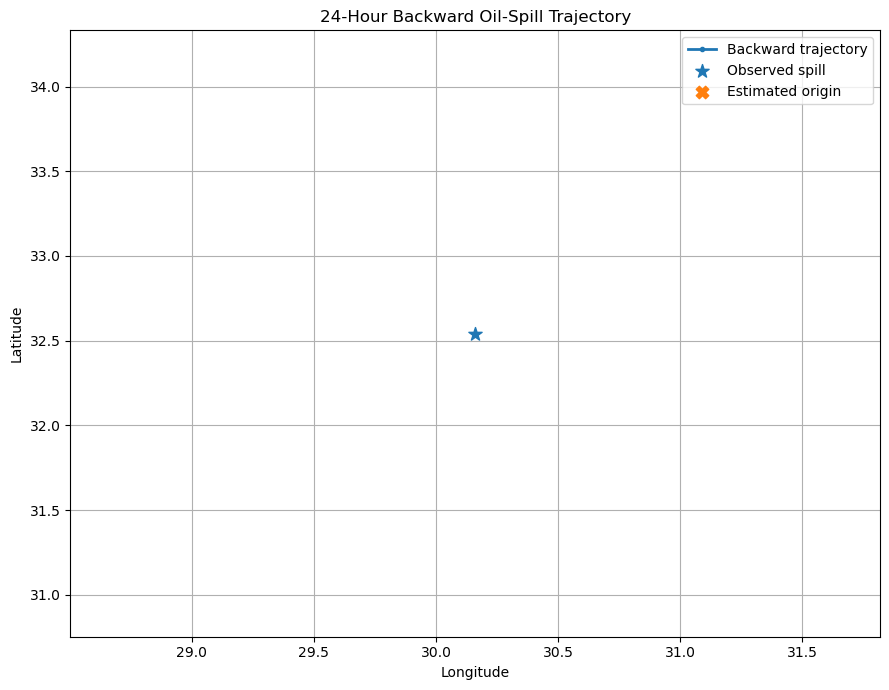

Estimated origin after 24 hours:
Latitude : nan
Longitude: nan


In [35]:
# Cell 34 — Visualize backward trajectory

plt.figure(figsize=(9, 7))

plt.plot(
    trajectory_df["longitude"],
    trajectory_df["latitude"],
    marker="o",
    markersize=3,
    linewidth=2,
    label="Backward trajectory"
)

# Observed spill location
plt.scatter(
    spill_lon,
    spill_lat,
    s=100,
    marker="*",
    label="Observed spill"
)

# Oldest estimated position
oldest = trajectory_df.iloc[-1]

plt.scatter(
    oldest["longitude"],
    oldest["latitude"],
    s=80,
    marker="X",
    label="Estimated origin"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("24-Hour Backward Oil-Spill Trajectory")

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

print("Estimated origin after 24 hours:")
print(f"Latitude : {oldest['latitude']:.6f}")
print(f"Longitude: {oldest['longitude']:.6f}")

In [36]:
# Cell 35 — Diagnose missing environmental values

print("Missing values in combined environment:")
print(
    environment_df[
        [
            "timestamp",
            "u10",
            "v10",
            "uo",
            "vo",
            "drift_u_ms",
            "drift_v_ms",
        ]
    ].isna().sum()
)

print("\nRows containing NaN:")
print(
    environment_df[
        environment_df[
            ["u10", "v10", "uo", "vo",
             "drift_u_ms", "drift_v_ms"]
        ].isna().any(axis=1)
    ]
)

Missing values in combined environment:
timestamp      0
u10            0
v10            0
uo            21
vo            21
drift_u_ms    21
drift_v_ms    21
dtype: int64

Rows containing NaN:
             timestamp       u10       v10  wind_speed_ms  wind_direction_deg  \
0  2019-10-18 00:00:00 -0.980545 -4.538528       4.643243           12.191315   
1  2019-10-18 01:00:00 -1.210251 -3.960495       4.141283           16.992126   
2  2019-10-18 02:00:00 -0.881073 -3.583923       3.690636           13.811707   
3  2019-10-18 03:00:00 -0.633331 -3.256989       3.317994           11.004028   
4  2019-10-18 04:00:00 -0.400711 -2.851456       2.879474            7.999298   
5  2019-10-18 05:00:00 -0.558975 -2.684677       2.742252           11.761475   
6  2019-10-18 06:00:00 -1.102188 -2.335022       2.582082           25.268463   
7  2019-10-18 07:00:00 -1.193253 -1.861191       2.210856           32.664856   
8  2019-10-18 08:00:00  0.549866 -2.175018       2.243448          345.812347

In [37]:
# Cell 36 — Download currents for exact 24h hindcast window

CURRENT_FILE = BASE / "med_current_2019-10-18_16_19-10-16.nc"

current_result = copernicusmarine.subset(
    dataset_id="cmems_mod_med_phy-cur_my_4.2km_PT1H-m",
    variables=["uo", "vo"],
    minimum_longitude=29.75,
    maximum_longitude=30.50,
    minimum_latitude=32.15,
    maximum_latitude=32.90,
    minimum_depth=0,
    maximum_depth=1,
    start_datetime="2019-10-18T15:00:00",
    end_datetime="2019-10-19T16:00:00",
    coordinates_selection_method="nearest",
    output_filename=str(CURRENT_FILE),
)

print("Corrected current data downloaded:")
print(CURRENT_FILE)

INFO - 2026-09-06T15:22:00Z - Selected dataset version: "202511"
INFO - 2026-09-06T15:22:00Z - Selected dataset part: "default"
INFO - 2026-09-06T15:22:09Z - Total size of the download: 86.68 KB.


Corrected current data downloaded:
/Volumes/Utkash SSD/SIH26143/med_current_2019-10-18_16_19-10-16.nc


In [38]:
# Cell 37 — Load and verify corrected ocean-current data

CURRENT_FILE = BASE / "med_current_2019-10-18_16_19-10-16.nc"

ocean = xr.open_dataset(CURRENT_FILE)

print(ocean)

print("\nVariables:")
print(list(ocean.data_vars))

print("\nTime range:")
print(ocean.time.values[0])
print(ocean.time.values[-1])

print("\nNumber of time points:")
print(ocean.sizes["time"])

print("\nCurrent grid:")
print("Latitude:", ocean.latitude.values.min(), "to", ocean.latitude.values.max())
print("Longitude:", ocean.longitude.values.min(), "to", ocean.longitude.values.max())

<xarray.Dataset> Size: 75kB
Dimensions:    (time: 26, latitude: 19, longitude: 19)
Coordinates:
  * time       (time) datetime64[ns] 208B 2019-10-18T15:00:00 ... 2019-10-19T...
  * latitude   (latitude) float32 76B 32.15 32.19 32.23 ... 32.81 32.85 32.9
  * longitude  (longitude) float32 76B 29.75 29.79 29.83 ... 30.42 30.46 30.5
Data variables:
    uo         (time, latitude, longitude) float32 38kB ...
    vo         (time, latitude, longitude) float32 38kB ...
Attributes:
    Conventions:               CF-1.0
    bulletin_date:             20230707
    bulletin_type:             interim
    comment:                   Please check in CMEMS catalogue the INFO secti...
    contact:                   servicedesk.cmems@mercator-ocean.eu
    field_type:                hourly_mean_centered_at_time_field
    institution:               Centro Euro-Mediterraneo sui Cambiamenti Clima...
    references:                Escudier, R., Clementi, E., Omar, M., Cipollon...
    source:                

In [39]:
# Cell 38 — Extract ocean current at spill location

current_at_spill = ocean.sel(
    latitude=spill_lat,
    longitude=spill_lon,
    method="nearest"
)

print("Nearest current grid point:")
print("Latitude :", float(current_at_spill.latitude.values))
print("Longitude:", float(current_at_spill.longitude.values))

print("\nTime range:")
print(current_at_spill.time.values[0])
print(current_at_spill.time.values[-1])

print("\nNumber of current observations:")
print(current_at_spill.sizes["time"])

Nearest current grid point:
Latitude : 32.5625
Longitude: 30.16666603088379

Time range:
2019-10-18T15:00:00.000000000
2019-10-19T16:00:00.000000000

Number of current observations:
26


In [40]:
# Cell 39 — Prepare corrected ocean-current dataframe

current_df = current_at_spill[["uo", "vo"]].to_dataframe().reset_index()

current_df = current_df[["time", "uo", "vo"]].copy()

current_df["current_speed_ms"] = np.sqrt(
    current_df["uo"]**2 + current_df["vo"]**2
)

current_df["current_direction_deg"] = (
    np.degrees(
        np.arctan2(
            current_df["uo"],
            current_df["vo"]
        )
    ) + 360
) % 360

print(current_df)

print("\nMissing values:")
print(current_df[["uo", "vo"]].isna().sum())

print("\nCurrent speed:")
print(
    current_df["current_speed_ms"].describe()
)

                  time        uo        vo  current_speed_ms  \
0  2019-10-18 15:00:00 -0.119834  0.088908          0.149214   
1  2019-10-18 16:00:00 -0.128705  0.103883          0.165398   
2  2019-10-18 17:00:00 -0.137004  0.116410          0.179781   
3  2019-10-18 18:00:00 -0.144049  0.129860          0.193943   
4  2019-10-18 19:00:00 -0.150409  0.146447          0.209928   
5  2019-10-18 20:00:00 -0.153755  0.165822          0.226136   
6  2019-10-18 21:00:00 -0.150936  0.186199          0.239691   
7  2019-10-18 22:00:00 -0.139849  0.204274          0.247559   
8  2019-10-18 23:00:00 -0.122687  0.217157          0.249418   
9  2019-10-19 00:00:00 -0.103321  0.221925          0.244798   
10 2019-10-19 01:00:00 -0.081933  0.220930          0.235633   
11 2019-10-19 02:00:00 -0.060953  0.214829          0.223308   
12 2019-10-19 03:00:00 -0.040459  0.206074          0.210008   
13 2019-10-19 04:00:00 -0.021493  0.194702          0.195884   
14 2019-10-19 05:00:00 -0.006380  0.1800

In [41]:
# Cell 40 — Merge wind and ocean current for the hindcast window

wind_for_merge = wind_df.rename(
    columns={"valid_time": "timestamp"}
).copy()

current_for_merge = current_df.rename(
    columns={"time": "timestamp"}
).copy()

# Make both timestamps timezone-naive for merging
wind_for_merge["timestamp"] = (
    pd.to_datetime(wind_for_merge["timestamp"], utc=True)
    .dt.tz_localize(None)
)

current_for_merge["timestamp"] = (
    pd.to_datetime(current_for_merge["timestamp"], utc=True)
    .dt.tz_localize(None)
)

# Restrict wind to the period covered by ocean-current data
hindcast_start = pd.Timestamp("2019-10-18 15:00:00")
hindcast_end = pd.Timestamp("2019-10-19 16:00:00")

wind_for_merge = wind_for_merge[
    (wind_for_merge["timestamp"] >= hindcast_start) &
    (wind_for_merge["timestamp"] <= hindcast_end)
].copy()

current_for_merge = current_for_merge[
    (current_for_merge["timestamp"] >= hindcast_start) &
    (current_for_merge["timestamp"] <= hindcast_end)
].copy()

environment_df = pd.merge_asof(
    wind_for_merge.sort_values("timestamp"),
    current_for_merge.sort_values("timestamp"),
    on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("1 hour"),
)

print("Environment rows:", len(environment_df))

print("\nMissing values:")
print(
    environment_df[
        ["u10", "v10", "uo", "vo"]
    ].isna().sum()
)

print("\nTime range:")
print(environment_df["timestamp"].iloc[0])
print(environment_df["timestamp"].iloc[-1])

print("\nEnvironment preview:")
print(
    environment_df[
        [
            "timestamp",
            "u10",
            "v10",
            "uo",
            "vo",
        ]
    ].head()
)

Environment rows: 26

Missing values:
u10    0
v10    0
uo     0
vo     0
dtype: int64

Time range:
2019-10-18 15:00:00
2019-10-19 16:00:00

Environment preview:
            timestamp       u10       v10        uo        vo
0 2019-10-18 15:00:00 -3.089828 -2.703018 -0.119834  0.088908
1 2019-10-18 16:00:00  0.686813 -2.132339 -0.128705  0.103883
2 2019-10-18 17:00:00  2.236389 -2.477280 -0.137004  0.116410
3 2019-10-18 18:00:00  1.969162 -2.891251 -0.144049  0.129860
4 2019-10-18 19:00:00  0.454208 -2.906250 -0.150409  0.146447


In [42]:
# Cell 41 — Calculate combined surface drift velocity

WINDAGE_FACTOR = 0.03

environment_df["drift_u_ms"] = (
    environment_df["uo"]
    + WINDAGE_FACTOR * environment_df["u10"]
)

environment_df["drift_v_ms"] = (
    environment_df["vo"]
    + WINDAGE_FACTOR * environment_df["v10"]
)

environment_df["drift_speed_ms"] = np.sqrt(
    environment_df["drift_u_ms"]**2
    + environment_df["drift_v_ms"]**2
)

print("Missing drift values:")
print(
    environment_df[
        ["drift_u_ms", "drift_v_ms", "drift_speed_ms"]
    ].isna().sum()
)

print("\nDrift speed statistics:")
print(
    environment_df["drift_speed_ms"].describe()
)

print("\nSample:")
print(
    environment_df[
        [
            "timestamp",
            "uo",
            "vo",
            "u10",
            "v10",
            "drift_u_ms",
            "drift_v_ms",
            "drift_speed_ms",
        ]
    ].head()
)

Missing drift values:
drift_u_ms        0
drift_v_ms        0
drift_speed_ms    0
dtype: int64

Drift speed statistics:
count    26.000000
mean      0.155805
std       0.049998
min       0.081605
25%       0.114482
50%       0.144674
75%       0.209057
max       0.226701
Name: drift_speed_ms, dtype: float64

Sample:
            timestamp        uo        vo       u10       v10  drift_u_ms  \
0 2019-10-18 15:00:00 -0.119834  0.088908 -3.089828 -2.703018   -0.212529   
1 2019-10-18 16:00:00 -0.128705  0.103883  0.686813 -2.132339   -0.108100   
2 2019-10-18 17:00:00 -0.137004  0.116410  2.236389 -2.477280   -0.069912   
3 2019-10-18 18:00:00 -0.144049  0.129860  1.969162 -2.891251   -0.084974   
4 2019-10-18 19:00:00 -0.150409  0.146447  0.454208 -2.906250   -0.136783   

   drift_v_ms  drift_speed_ms  
0    0.007818        0.212673  
1    0.039913        0.115233  
2    0.042091        0.081605  
3    0.043123        0.095290  
4    0.059259        0.149068  


In [43]:
# Cell 42 — 24-hour backward trajectory

from math import cos, radians

# Keep only valid environmental data
trajectory_data = environment_df.dropna(
    subset=["drift_u_ms", "drift_v_ms"]
).sort_values(
    "timestamp",
    ascending=False
).copy()

# Use exactly 24 hourly steps
trajectory_data = trajectory_data.iloc[:24].copy()

trajectory = []

current_lat = float(spill_lat)
current_lon = float(spill_lon)

for _, row in trajectory_data.iterrows():

    # Store current position before moving backward
    trajectory.append({
        "timestamp": row["timestamp"],
        "latitude": current_lat,
        "longitude": current_lon,
        "drift_u_ms": row["drift_u_ms"],
        "drift_v_ms": row["drift_v_ms"],
        "drift_speed_ms": row["drift_speed_ms"],
    })

    # One-hour backward integration
    dt = 3600.0

    meters_per_degree_lat = 111_320.0
    meters_per_degree_lon = (
        111_320.0 * cos(radians(current_lat))
    )

    current_lon -= (
        row["drift_u_ms"] * dt
        / meters_per_degree_lon
    )

    current_lat -= (
        row["drift_v_ms"] * dt
        / meters_per_degree_lat
    )

trajectory_df = pd.DataFrame(trajectory)

print("Trajectory points:", len(trajectory_df))

print("\nStart:")
print(trajectory_df.iloc[0])

print("\nEstimated 24-hour origin:")
print("Latitude :", f"{current_lat:.6f}")
print("Longitude:", f"{current_lon:.6f}")

print("\nPosition displacement:")
print("Latitude :", f"{current_lat - spill_lat:+.6f}°")
print("Longitude:", f"{current_lon - spill_lon:+.6f}°")

Trajectory points: 24

Start:
timestamp         2019-10-19 16:00:00
latitude                    32.541974
longitude                   30.160444
drift_u_ms                  -0.220149
drift_v_ms                  -0.011103
drift_speed_ms               0.220429
Name: 0, dtype: object

Estimated 24-hour origin:
Latitude : 32.475485
Longitude: 30.262257

Position displacement:
Latitude : -0.066489°
Longitude: +0.101813°


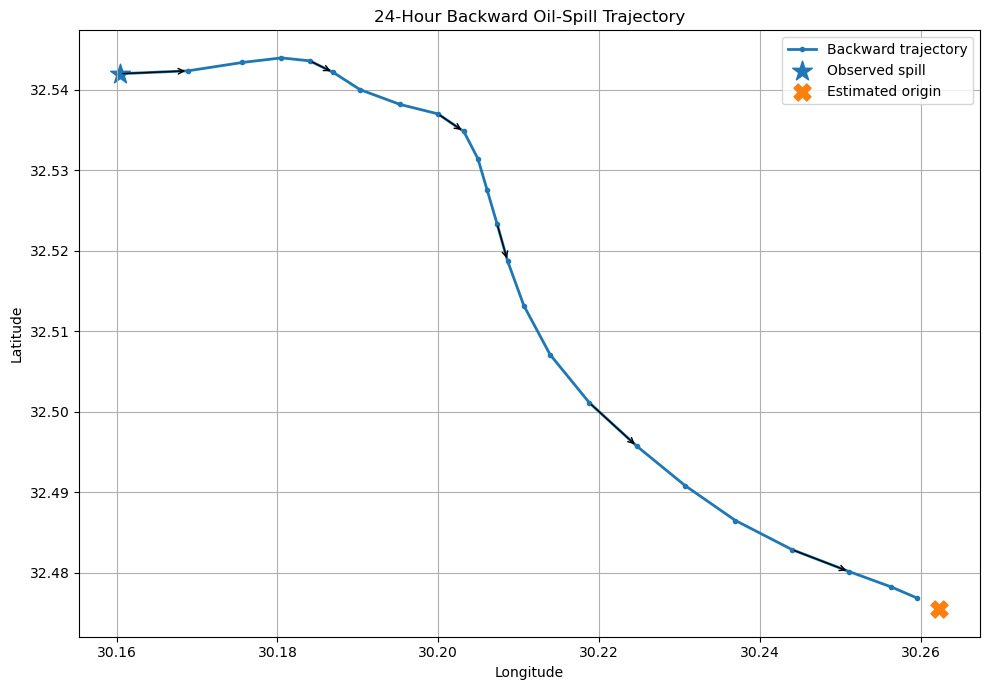

Observed spill:
  Latitude : 32.541974
  Longitude: 30.160444

Estimated origin after 24 hours:
  Latitude : 32.475485
  Longitude: 30.262257

Approximate displacement:
  Δ Latitude : -0.066489°
  Δ Longitude: +0.101813°


In [44]:
# Cell 43 — Visualize 24-hour backward trajectory

plt.figure(figsize=(10, 7))

# Backward trajectory
plt.plot(
    trajectory_df["longitude"],
    trajectory_df["latitude"],
    marker="o",
    markersize=3,
    linewidth=2,
    label="Backward trajectory"
)

# Observed spill location
plt.scatter(
    spill_lon,
    spill_lat,
    marker="*",
    s=220,
    label="Observed spill"
)

# Estimated origin
origin_lat = float(current_lat)
origin_lon = float(current_lon)

plt.scatter(
    origin_lon,
    origin_lat,
    marker="X",
    s=150,
    label="Estimated origin"
)

# Add arrows at a few points
for i in range(0, len(trajectory_df) - 1, 4):
    x1 = trajectory_df.iloc[i]["longitude"]
    y1 = trajectory_df.iloc[i]["latitude"]
    x2 = trajectory_df.iloc[i + 1]["longitude"]
    y2 = trajectory_df.iloc[i + 1]["latitude"]

    plt.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1
        )
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("24-Hour Backward Oil-Spill Trajectory")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Observed spill:")
print(f"  Latitude : {spill_lat:.6f}")
print(f"  Longitude: {spill_lon:.6f}")

print("\nEstimated origin after 24 hours:")
print(f"  Latitude : {origin_lat:.6f}")
print(f"  Longitude: {origin_lon:.6f}")

print("\nApproximate displacement:")
print(f"  Δ Latitude : {origin_lat - spill_lat:+.6f}°")
print(f"  Δ Longitude: {origin_lon - spill_lon:+.6f}°")

In [45]:
# Cell 44 — Particle-based origin uncertainty

import numpy as np
import pandas as pd

np.random.seed(42)

NUM_PARTICLES = 500
INITIAL_UNCERTAINTY_KM = 1.0
DRIFT_NOISE_FRACTION = 0.10

particle_lat = np.full(NUM_PARTICLES, float(spill_lat))
particle_lon = np.full(NUM_PARTICLES, float(spill_lon))

# Initial position uncertainty (~1 km)
lat_noise_deg = (
    np.random.normal(0, INITIAL_UNCERTAINTY_KM, NUM_PARTICLES)
    / 111.32
)

lon_noise_deg = (
    np.random.normal(0, INITIAL_UNCERTAINTY_KM, NUM_PARTICLES)
    / (
        111.32 * np.cos(np.radians(spill_lat))
    )
)

particle_lat += lat_noise_deg
particle_lon += lon_noise_deg

# Backward integration
for _, row in trajectory_data.iterrows():

    drift_u = row["drift_u_ms"]
    drift_v = row["drift_v_ms"]

    # Small uncertainty in environmental forcing
    u_particles = drift_u * (
        1 + np.random.normal(
            0,
            DRIFT_NOISE_FRACTION,
            NUM_PARTICLES
        )
    )

    v_particles = drift_v * (
        1 + np.random.normal(
            0,
            DRIFT_NOISE_FRACTION,
            NUM_PARTICLES
        )
    )

    dt = 3600.0

    meters_per_degree_lat = 111_320.0
    meters_per_degree_lon = (
        111_320.0
        * np.cos(np.radians(particle_lat))
    )

    # Backward movement
    particle_lon -= (
        u_particles * dt
        / meters_per_degree_lon
    )

    particle_lat -= (
        v_particles * dt
        / meters_per_degree_lat
    )

origin_particles = pd.DataFrame({
    "latitude": particle_lat,
    "longitude": particle_lon
})

print("Particles:", len(origin_particles))

print("\nEstimated origin region:")
print(
    "Latitude :",
    f"{origin_particles['latitude'].mean():.6f}"
)
print(
    "Longitude:",
    f"{origin_particles['longitude'].mean():.6f}"
)

print("\nUncertainty:")
print(
    "Latitude std :",
    f"{origin_particles['latitude'].std():.6f}°"
)
print(
    "Longitude std:",
    f"{origin_particles['longitude'].std():.6f}°"
)

print("\nOrigin bounds:")
print(
    f"Latitude : "
    f"{origin_particles['latitude'].min():.6f}"
    f" → "
    f"{origin_particles['latitude'].max():.6f}"
)
print(
    f"Longitude: "
    f"{origin_particles['longitude'].min():.6f}"
    f" → "
    f"{origin_particles['longitude'].max():.6f}"
)

Particles: 500

Estimated origin region:
Latitude : 32.475501
Longitude: 30.262603

Uncertainty:
Latitude std : 0.008993°
Longitude std: 0.010745°

Origin bounds:
Latitude : 32.448202 → 32.510008
Longitude: 30.232644 → 30.293181


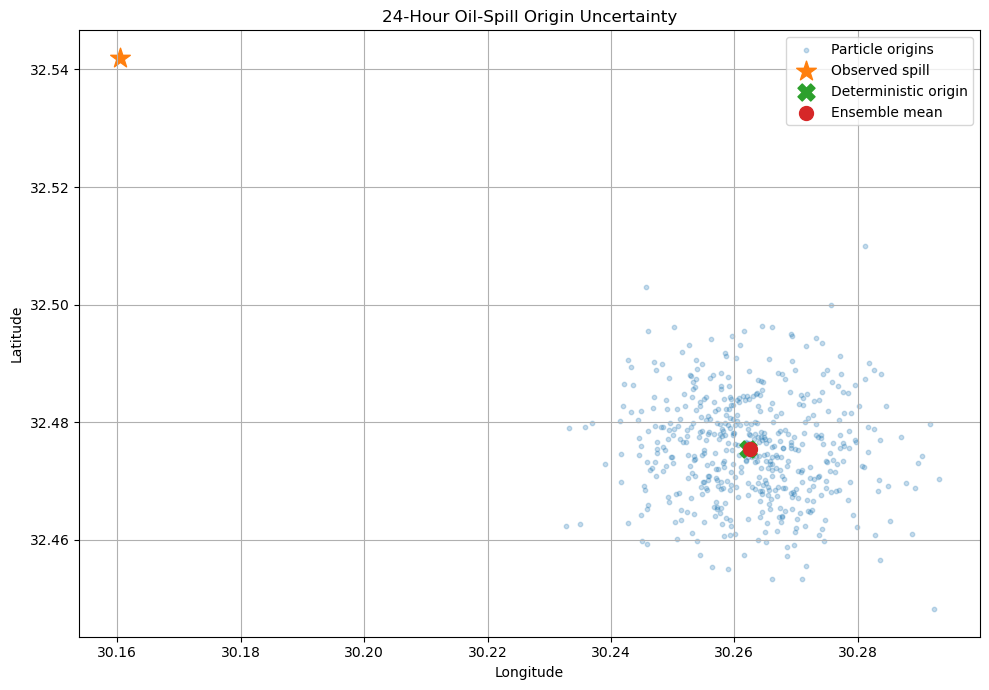

Ensemble mean origin:
  Latitude : 32.475501
  Longitude: 30.262603

Origin uncertainty:
  Latitude std  : 0.008993°
  Longitude std : 0.010745°


In [46]:
# Cell 45 — Visualize particle-based origin uncertainty

plt.figure(figsize=(10, 7))

# Particle origin cloud
plt.scatter(
    origin_particles["longitude"],
    origin_particles["latitude"],
    s=10,
    alpha=0.25,
    label="Particle origins"
)

# Observed spill
plt.scatter(
    spill_lon,
    spill_lat,
    marker="*",
    s=220,
    label="Observed spill"
)

# Deterministic origin
plt.scatter(
    origin_lon,
    origin_lat,
    marker="X",
    s=150,
    label="Deterministic origin"
)

# Ensemble mean origin
ensemble_lat = origin_particles["latitude"].mean()
ensemble_lon = origin_particles["longitude"].mean()

plt.scatter(
    ensemble_lon,
    ensemble_lat,
    marker="o",
    s=100,
    label="Ensemble mean"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("24-Hour Oil-Spill Origin Uncertainty")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Ensemble mean origin:")
print(f"  Latitude : {ensemble_lat:.6f}")
print(f"  Longitude: {ensemble_lon:.6f}")

print("\nOrigin uncertainty:")
print(f"  Latitude std  : {origin_particles['latitude'].std():.6f}°")
print(f"  Longitude std : {origin_particles['longitude'].std():.6f}°")

In [47]:
# Cell 46 — Calculate probable origin region from particle ensemble

# 95% approximate confidence bounds
lat_lower = origin_particles["latitude"].quantile(0.025)
lat_upper = origin_particles["latitude"].quantile(0.975)

lon_lower = origin_particles["longitude"].quantile(0.025)
lon_upper = origin_particles["longitude"].quantile(0.975)

origin_region = {
    "center": {
        "latitude": float(ensemble_lat),
        "longitude": float(ensemble_lon),
    },
    "bounds": {
        "min_latitude": float(lat_lower),
        "max_latitude": float(lat_upper),
        "min_longitude": float(lon_lower),
        "max_longitude": float(lon_upper),
    },
    "particle_count": int(len(origin_particles)),
    "confidence_level": 0.95,
}

print("Probable Origin Region (95%):")
print(
    f"Latitude : "
    f"{lat_lower:.6f} → {lat_upper:.6f}"
)
print(
    f"Longitude: "
    f"{lon_lower:.6f} → {lon_upper:.6f}"
)

print("\nOrigin center:")
print(f"Latitude : {ensemble_lat:.6f}")
print(f"Longitude: {ensemble_lon:.6f}")

print("\nParticles:", len(origin_particles))
print("Confidence level: 95%")

Probable Origin Region (95%):
Latitude : 32.459423 → 32.493904
Longitude: 30.243041 → 30.283669

Origin center:
Latitude : 32.475501
Longitude: 30.262603

Particles: 500
Confidence level: 95%


In [48]:
# Cell 47 — Save complete Phase 3 hindcast result

phase3_result = {
    "observation": {
        "timestamp": str(observation_timestamp),
        "latitude": float(spill_lat),
        "longitude": float(spill_lon),
    },

    "hindcast": {
        "backtrack_hours": 24,
        "time_step_hours": 1,
        "windage_factor": WINDAGE_FACTOR,
        "trajectory_points": int(len(trajectory_df)),
    },

    "deterministic_origin": {
        "latitude": float(origin_lat),
        "longitude": float(origin_lon),
    },

    "ensemble_origin": {
        "latitude": float(ensemble_lat),
        "longitude": float(ensemble_lon),
        "particle_count": int(len(origin_particles)),
        "confidence_level": 0.95,
    },

    "probable_origin_region": {
        "min_latitude": float(lat_lower),
        "max_latitude": float(lat_upper),
        "min_longitude": float(lon_lower),
        "max_longitude": float(lon_upper),
    },

    "environmental_data": {
        "wind_source": "ERA5 hourly 10m wind",
        "current_source": "Copernicus Marine Mediterranean Physics Reanalysis",
    },
}

PHASE3_RESULT_PATH = BASE / "phase3_hindcast_result.json"

with open(PHASE3_RESULT_PATH, "w") as f:
    json.dump(phase3_result, f, indent=2)

print("Phase 3 result saved:")
print(PHASE3_RESULT_PATH)

print("\n" + "=" * 50)
print("PHASE 3 — HINDCAST SUMMARY")
print("=" * 50)

print(
    f"Observed spill : "
    f"{spill_lat:.6f}, {spill_lon:.6f}"
)

print(
    f"Origin estimate: "
    f"{ensemble_lat:.6f}, {ensemble_lon:.6f}"
)

print(
    f"95% region     : "
    f"{lat_lower:.6f}–{lat_upper:.6f} N, "
    f"{lon_lower:.6f}–{lon_upper:.6f} E"
)

print(f"Particles      : {len(origin_particles)}")
print(f"Backtrack      : {BACKTRACK_HOURS} hours")

Phase 3 result saved:
/Volumes/Utkash SSD/SIH26143/phase3_hindcast_result.json

PHASE 3 — HINDCAST SUMMARY
Observed spill : 32.541974, 30.160444
Origin estimate: 32.475501, 30.262603
95% region     : 32.459423–32.493904 N, 30.243041–30.283669 E
Particles      : 500
Backtrack      : 24 hours
